**Goal:** Visually explore patterns in delivery performance, 
identify SLA breach drivers, and produce various charts 
that tell a complete business story.

**Input:** `../data/processed/orders_clean.csv`  
**Output:** Charts saved to `../dashboard/screenshots/`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# global chart styling — consistent look across all charts
sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

OUTPUT_DIR = '../dashboard/screenshots/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Setup complete. Charts will save to:", OUTPUT_DIR)

Setup complete. Charts will save to: ../dashboard/screenshots/


In [2]:
df = pd.read_csv('../data/processed/orders_clean.csv')

# restore correct dtypes after CSV round-trip
df['sla_breached'] = df['sla_breached'].astype(bool)
df['is_weekend']   = df['is_weekend'].astype(bool)
df['order_date']   = pd.to_datetime(df['order_date'], errors='coerce')

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nSLA breach rate: {df['sla_breached'].mean()*100:.2f}%")
print(f"Avg delivery time: {df['time_taken_min'].mean():.1f} min")
print(f"Median delivery time: {df['time_taken_min'].median():.0f} min")

Loaded: 43,853 rows × 28 columns

SLA breach rate: 29.83%
Avg delivery time: 26.3 min
Median delivery time: 26 min


### Chart 1: Delivery Time Distribution

**What we are looking for:**
- Is the distribution normal, right-skewed, or bimodal?
- Where does the bulk of orders fall relative to the 30-min SLA?
- What % of orders are clearly fast vs clearly late?

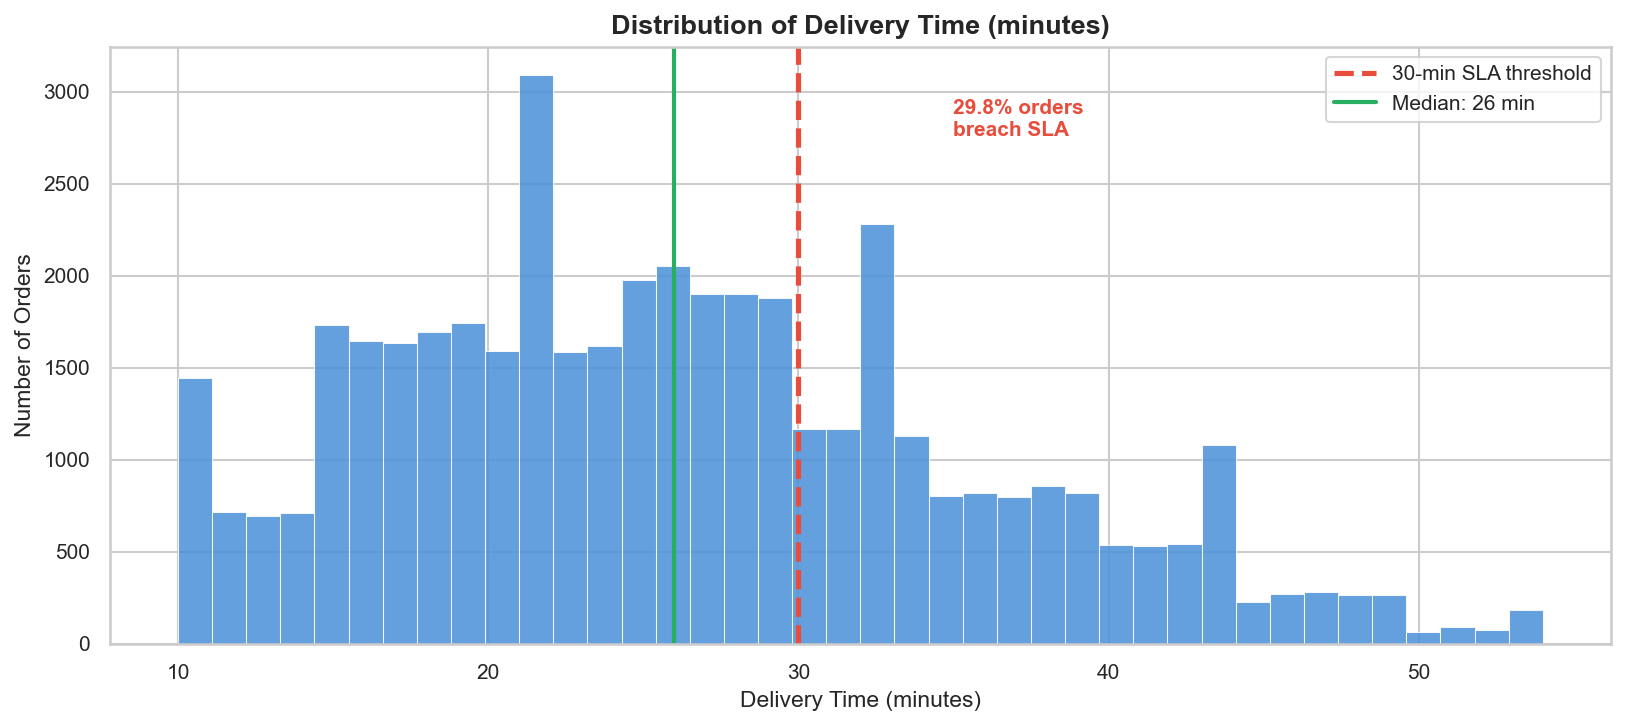

Chart 1 saved.


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(
    df['time_taken_min'],
    bins=40,
    color='#4A90D9',
    edgecolor='white',
    linewidth=0.5,
    alpha=0.85
)

# SLA threshold line
ax.axvline(x=30, color='#E74C3C', linewidth=2.5,
           linestyle='--', label='30-min SLA threshold')

# Median line
median_val = df['time_taken_min'].median()
ax.axvline(x=median_val, color='#27AE60', linewidth=2,
           linestyle='-', label=f'Median: {median_val:.0f} min')

# Annotations
breach_pct = df['sla_breached'].mean() * 100
ax.text(35, ax.get_ylim()[1]*0.85,
        f'{breach_pct:.1f}% orders\nbreach SLA',
        color='#E74C3C', fontsize=10, fontweight='bold')

ax.set_title('Distribution of Delivery Time (minutes)')
ax.set_xlabel('Delivery Time (minutes)')
ax.set_ylabel('Number of Orders')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'chart01_delivery_time_distribution.png',
            bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

**Business Interpretation - Chart 1:**
Delivery times are spread evenly between 20–50 minutes, showing no strong focus around the 30-minute SLA target.
Although the median delivery time is 26 minutes (below the SLA), a large percentage of orders still exceed 30 minutes. This suggests the SLA is being followed loosely rather than strictly.


### Chart 2: SLA Breach Rate by City Tier

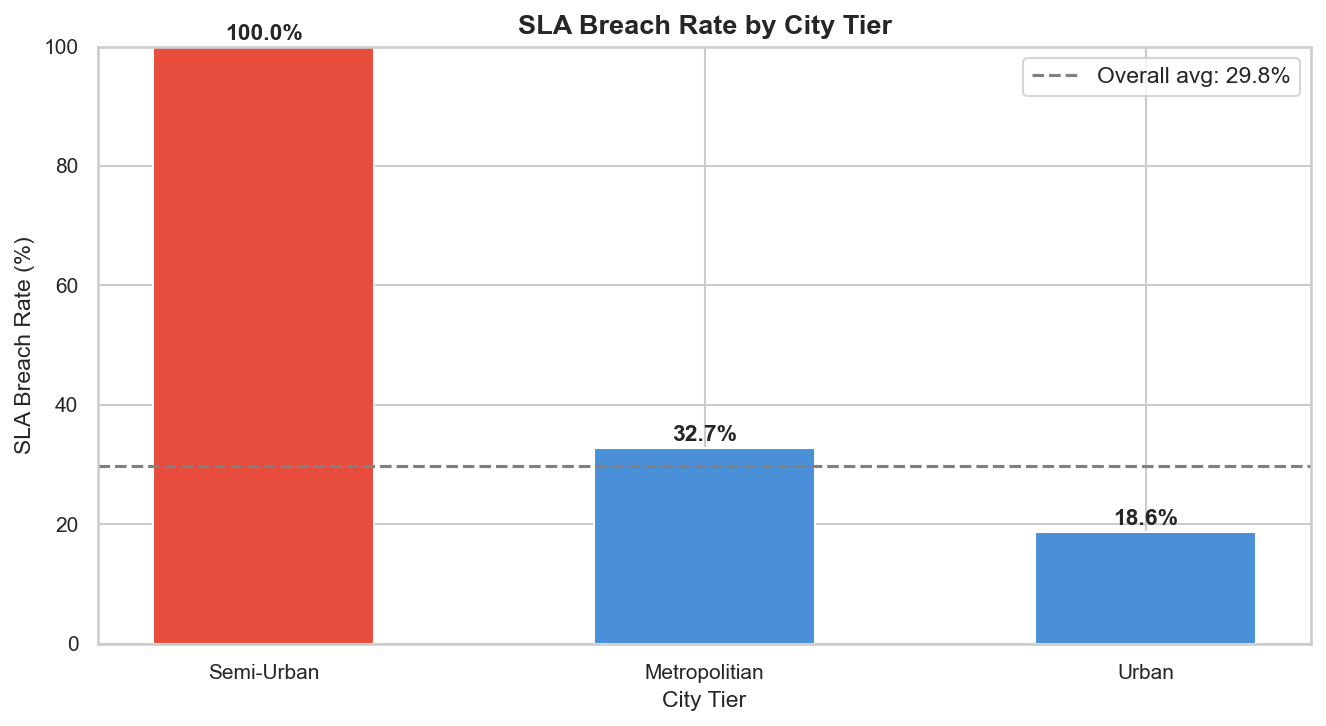


City stats:
         city  total_orders  breach_pct  avg_time
   Semi-Urban           156      100.00 49.737179
Metropolitian         33940       32.72 27.132322
        Urban          9757       18.64 22.999283


In [4]:
city_stats = (
    df.groupby('city')
    .agg(
        total_orders   = ('order_id', 'count'),
        breach_pct     = ('sla_breached', lambda x: round(x.mean()*100, 2)),
        avg_time       = ('time_taken_min', 'mean')
    )
    .reset_index()
    .sort_values('breach_pct', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    city_stats['city'],
    city_stats['breach_pct'],
    color=['#E74C3C' if v > 50 else '#4A90D9' for v in city_stats['breach_pct']],
    edgecolor='white', width=0.5
)

# add value labels on bars
for bar, val in zip(bars, city_stats['breach_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', va='bottom',
            fontweight='bold', fontsize=11)

ax.axhline(y=df['sla_breached'].mean()*100,
           color='grey', linestyle='--', linewidth=1.5,
           label=f'Overall avg: {df["sla_breached"].mean()*100:.1f}%')

ax.set_title('SLA Breach Rate by City Tier')
ax.set_xlabel('City Tier')
ax.set_ylabel('SLA Breach Rate (%)')
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'chart02_sla_breach_by_city.png', bbox_inches='tight')
plt.show()

print("\nCity stats:")
print(city_stats.to_string(index=False))